In [1]:
import pandas as pd
pd.set_option('display.float_format', '{:.2f}'.format)

import matplotlib.pyplot as plt
import numpy as np


df_customers = pd.read_csv("/media/ion/4T/Wealthreader_datasets/N_50K/wealthreader_synthetic_customers_N_50K.csv")
df_portfolios = pd.read_csv("/media/ion/4T/Wealthreader_datasets/N_50K/wealthreader_synthetic_portfolios_N_50K.csv")
df_transactions = pd.read_csv("/media/ion/4T/Wealthreader_datasets/N_50K/wealthreader_synthetic_transactions_N_50K.csv")

### Inspección básica de la estructura

In [2]:
df_customers.shape

(50000, 44)

In [3]:
df_portfolios.shape

(60080, 10)

In [4]:
df_transactions.shape

(18000533, 7)

### Visualización de muestras

In [5]:
df_customers.head(10)

,customer_id,perfil_real,edad,birth_date,estado_civil,categoria_laboral,zona_postal,n_cuentas,n_cuentas_corrientes,n_depositos_plazo,...,cuota_mensual,tipo_interes,porcentaje_amortizado,años_restantes,tiene_seguro,suma_asegurada,n_domiciliaciones,importe_total_domiciliaciones,tiene_recibos_rechazados,default_12m
0,1,medio,42,1983-11-08,soltero,empleado,D,3,2,2,...,0.00,0.00,0.00,0.00,1,59533.75,5,336.59,0,0
1,2,bajo_riesgo,52,1973-06-27,casado,funcionario,C,3,2,2,...,0.00,0.00,0.00,0.00,1,374663.39,9,557.51,0,0
2,3,alto_riesgo,39,1986-12-04,soltero,autonomo,C,3,2,0,...,0.00,0.00,0.00,0.00,0,0.00,5,263.06,0,1
3,4,alto_riesgo,25,2000-01-22,soltero,empleado,D,3,3,0,...,72.85,0.09,0.70,0.90,0,0.00,4,241.26,0,1
4,5,medio,36,1989-05-27,soltero,jubilado,A,3,3,0,...,998.78,0.02,0.54,13.20,0,0.00,9,605.98,0,0
5,6,bajo_riesgo,42,1983-09-09,soltero,desempleado,A,3,2,0,...,866.82,0.04,0.62,7.90,0,0.00,3,249.45,0,0
6,7,bajo_riesgo,52,1973-05-28,casado,funcionario,B,3,2,0,...,0.00,0.00,0.00,0.00,1,284951.72,6,611.54,0,0
7,8,medio,36,1989-06-23,casado,autonomo,B,1,1,0,...,254.00,0.05,0.27,4.40,0,0.00,7,264.85,0,1
8,9,medio,39,1986-02-05,casado,funcionario,C,1,1,0,...,184.10,0.05,0.71,1.20,0,0.00,7,547.28,0,0
9,10,medio,33,1992-01-10,soltero,jubilado,C,1,1,0,...,0.00,0.00,0.00,0.00,1,65651.80,7,273.81,1,0


In [6]:
df_portfolios.head(10)

,customer_id,isin,nombre,tipo_producto,participaciones,valor_liquidativo,valor_posicion,weighted_return,contributions,fecha_valoracion
0,1,IE00B4L5Y983,ETF MSCI World,ETF,105.08,61.54,6467.22,0.05,1160.64,2025-12-30
1,1,ES0152743039,Plan Pensiones Balanced,PP,12.07,154.44,1863.69,0.04,334.47,2025-12-30
2,1,ES0138045036,Fondo Renta Variable España,RV,15.32,59.80,916.08,-0.02,164.41,2025-12-30
3,2,ES0182769038,Fondo Bonos Gobierno,RF,200.55,64.67,12968.61,0.06,2117.71,2025-12-30
4,6,LU0996182563,Fondo Tecnología Global,RV,122.77,151.93,18651.59,0.07,2570.90,2025-12-30
5,6,LU0048573561,Fondo Global Allocation,MIXTO,355.03,143.79,51048.80,0.04,7036.48,2025-12-30
6,7,IE00B4L5Y983,ETF MSCI World,ETF,49.33,153.60,7577.32,0.13,1068.51,2025-12-30
7,7,LU0996182563,Fondo Tecnología Global,RV,107.33,83.15,8924.46,0.10,1258.48,2025-12-30
8,7,ES0182769038,Fondo Bonos Gobierno,RF,136.08,140.78,19157.19,0.10,2701.44,2025-12-30
9,10,ES0152743040,Plan Pensiones Conservador,PP,0.20,107.61,21.17,0.08,1.58,2025-12-30


In [7]:
df_transactions.head(10)

,customer_id,fecha,tipo,categoria,importe,balance,descripcion
0,1,2025-12-27T19:07:57.252869,INGRESO,NOMINA,2433.23,6109.72,NOMINA MES 1
1,1,2025-12-26T19:07:57.252869,GASTO,EDUCACION,-243.11,5866.61,Pago 1502
2,1,2025-12-24T19:07:57.252869,GASTO,ROPA,-194.99,5671.62,Pago 5488
3,1,2025-12-05T19:07:57.252869,GASTO,EDUCACION,-160.36,5511.27,Pago 8035
4,1,2025-12-24T19:07:57.252869,GASTO,SUPERMERCADO,-43.09,5468.17,Pago 9755
5,1,2025-12-27T19:07:57.252869,GASTO,VIAJES,-114.05,5354.12,Pago 8574
6,1,2025-12-16T19:07:57.252869,GASTO,ROPA,-109.35,5244.77,Pago 5636
7,1,2025-12-24T19:07:57.252869,GASTO,ROPA,-49.74,5195.02,Pago 4157
8,1,2025-12-21T19:07:57.252869,GASTO,TECNOLOGIA,-127.77,5067.25,Pago 3693
9,1,2025-12-19T19:07:57.252869,GASTO,HOGAR,-65.26,5001.99,Pago 6450


### Explorar tipos y nulos

In [8]:
df_customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 44 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   customer_id                    50000 non-null  int64  
 1   perfil_real                    50000 non-null  object 
 2   edad                           50000 non-null  int64  
 3   birth_date                     50000 non-null  object 
 4   estado_civil                   50000 non-null  object 
 5   categoria_laboral              50000 non-null  object 
 6   zona_postal                    50000 non-null  object 
 7   n_cuentas                      50000 non-null  int64  
 8   n_cuentas_corrientes           50000 non-null  int64  
 9   n_depositos_plazo              50000 non-null  int64  
 10  tiene_linea_credito            50000 non-null  int64  
 11  saldo_total                    50000 non-null  float64
 12  saldo_depositos                50000 non-null 

In [9]:
df_portfolios.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60080 entries, 0 to 60079
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        60080 non-null  int64  
 1   isin               60080 non-null  object 
 2   nombre             60080 non-null  object 
 3   tipo_producto      60080 non-null  object 
 4   participaciones    60080 non-null  float64
 5   valor_liquidativo  60080 non-null  float64
 6   valor_posicion     60080 non-null  float64
 7   weighted_return    60080 non-null  float64
 8   contributions      60080 non-null  float64
 9   fecha_valoracion   60080 non-null  object 
dtypes: float64(5), int64(1), object(4)
memory usage: 4.6+ MB


In [10]:
df_transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18000533 entries, 0 to 18000532
Data columns (total 7 columns):
 #   Column       Dtype  
---  ------       -----  
 0   customer_id  int64  
 1   fecha        object 
 2   tipo         object 
 3   categoria    object 
 4   importe      float64
 5   balance      float64
 6   descripcion  object 
dtypes: float64(2), int64(1), object(4)
memory usage: 961.3+ MB


**nota:** veo que no hay ningun valor nan por lo que sería interesante introducir un porcentage en el codigo del generador de data.

### Funcion visualización del tipo de dato que hay por columna y por dataset

In [11]:
def amount_dtypes(dataset):
    print(sorted(dataset.dtypes.value_counts().items()))

 **Objetivo de esta etapa**

Esta fase inicial busca responder preguntas como:
- ¿Qué tamaño tiene mi conjunto de datos?
  
    - df_customers(5000, 19)

    - df_portfolios(612, 8)

    - df_transactions(26045, 6)

- ¿Qué tipo de variables contiene (numéricas, categóricas, texto)?

In [12]:
amount_dtypes(df_transactions)

[(dtype('int64'), 1), (dtype('float64'), 2), (dtype('O'), 4)]


In [13]:
amount_dtypes(df_portfolios)

[(dtype('int64'), 1), (dtype('float64'), 5), (dtype('O'), 4)]


In [14]:
amount_dtypes(df_customers)

[(dtype('int64'), 17), (dtype('float64'), 21), (dtype('O'), 6)]


- ¿Hay datos faltantes?

In [15]:
df_transactions.isnull().sum()

customer_id    0
fecha          0
tipo           0
categoria      0
importe        0
balance        0
descripcion    0
dtype: int64

In [16]:
df_portfolios.isnull().sum()

customer_id          0
isin                 0
nombre               0
tipo_producto        0
participaciones      0
valor_liquidativo    0
valor_posicion       0
weighted_return      0
contributions        0
fecha_valoracion     0
dtype: int64

In [17]:
df_customers.isnull().sum()

customer_id                      0
perfil_real                      0
edad                             0
birth_date                       0
estado_civil                     0
categoria_laboral                0
zona_postal                      0
n_cuentas                        0
n_cuentas_corrientes             0
n_depositos_plazo                0
tiene_linea_credito              0
saldo_total                      0
saldo_depositos                  0
n_tarjetas                       0
tiene_tarjeta_credito            0
limite_credito_total             0
credito_dispuesto                0
ratio_utilizacion_credito        0
ingreso_medio_mensual            0
ingreso_std                      0
gasto_medio_mensual              0
gasto_std                        0
ahorro_medio_mensual             0
meses_ahorro_positivo            0
tiene_inversiones                0
tiene_plan_pensiones             0
valor_cartera                    0
n_fondos                         0
rentabilidad_cartera

In [18]:
df_customers['default_12m'].value_counts()

default_12m
0    41394
1     8606
Name: count, dtype: int64

In [19]:
counts = df_customers['default_12m'].value_counts()
porcentajes = counts / counts.sum() * 100
print(porcentajes)

default_12m
0   82.79
1   17.21
Name: count, dtype: float64


### Hay un 82.788% de ceros que de 1`s

**Advertencia:** Si tuviera 95% de 0s y 5% de 1s, tu dataset está desbalanceado. 

Esto es crítico porque afecta cómo entrenarás el modelo y qué métricas usarás. 

Un modelo que siempre diga "0" tendría 95% de accuracy pero sería inútil.

In [20]:
corr = df_customers.select_dtypes(include=[np.number]).corr()['default_12m'].sort_values()
print(corr)

meses_ahorro_positivo           -0.58
ingreso_medio_mensual           -0.42
ahorro_medio_mensual            -0.41
gasto_medio_mensual             -0.41
saldo_total                     -0.32
n_domiciliaciones               -0.31
ingreso_std                     -0.30
edad                            -0.30
suma_asegurada                  -0.29
tiene_seguro                    -0.26
limite_credito_total            -0.24
tiene_inversiones               -0.24
importe_total_domiciliaciones   -0.22
tiene_plan_pensiones            -0.21
rentabilidad_cartera            -0.21
valor_cartera                   -0.21
n_fondos                        -0.20
aportaciones_ultimo_año         -0.19
saldo_depositos                 -0.16
n_depositos_plazo               -0.15
tiene_tarjeta_credito           -0.07
credito_dispuesto               -0.06
n_tarjetas                      -0.05
gasto_std                       -0.02
customer_id                     -0.00
n_cuentas_corrientes            -0.00
n_cuentas   

Excelente. Resultados claros.

## Resumen de correlaciones

**🟢 Reducen riesgo (top predictores)**
| Variable | Corr | Comentario |
|----------|------|------------|
| `meses_ahorro_positivo` | -0.58 | ⭐ Mejor predictor |
| `ingreso_medio_mensual` | -0.42 | Redundante con ahorro |
| `ahorro_medio_mensual` | -0.41 | Redundante con ingreso |
| `saldo_total` | -0.32 | ✅ Incluir |
| `n_domiciliaciones` | -0.31 | ✅ NUEVO v4 |
| `edad` | -0.30 | ✅ NUEVO v4 |
| `tipo_interes` | +0.30 | ✅ NUEVO v4 (mayor interés = más riesgo) |

**🔴 Aumentan riesgo**
| Variable | Corr | Comentario |
|----------|------|------------|
| `tiene_recibos_rechazados` | +0.26 | ✅ NUEVO v4, muy predictivo |
| `ratio_utilizacion_credito` | +0.19 | ✅ NUEVO v4 |
| `tiene_prestamo` | +0.16 | Redundante con tipo_interes |

**⚪ No aportan (~0)**
- `n_cuentas`, `n_tarjetas`, `años_restantes`, `capital_original`, `customer_id`

---

**Siguiente paso:** Detectar redundancias entre features.





In [21]:
# Matriz de correlación entre features candidatas
features_candidatas = [
    'meses_ahorro_positivo', 'ingreso_medio_mensual', 'ahorro_medio_mensual',
    'saldo_total', 'n_domiciliaciones', 'edad', 'tiene_recibos_rechazados',
    'ratio_utilizacion_credito', 'tipo_interes', 'tiene_inversiones'
]
print(df_customers[features_candidatas].corr().round(2))

                           meses_ahorro_positivo  ingreso_medio_mensual  \
meses_ahorro_positivo                       1.00                   0.60   
ingreso_medio_mensual                       0.60                   1.00   
ahorro_medio_mensual                        0.59                   0.99   
saldo_total                                 0.44                   0.76   
n_domiciliaciones                           0.46                   0.56   
edad                                        0.45                   0.50   
tiene_recibos_rechazados                   -0.19                  -0.17   
ratio_utilizacion_credito                  -0.23                  -0.31   
tipo_interes                               -0.46                  -0.42   
tiene_inversiones                           0.33                   0.45   

                           ahorro_medio_mensual  saldo_total  \
meses_ahorro_positivo                      0.59         0.44   
ingreso_medio_mensual                      0.9

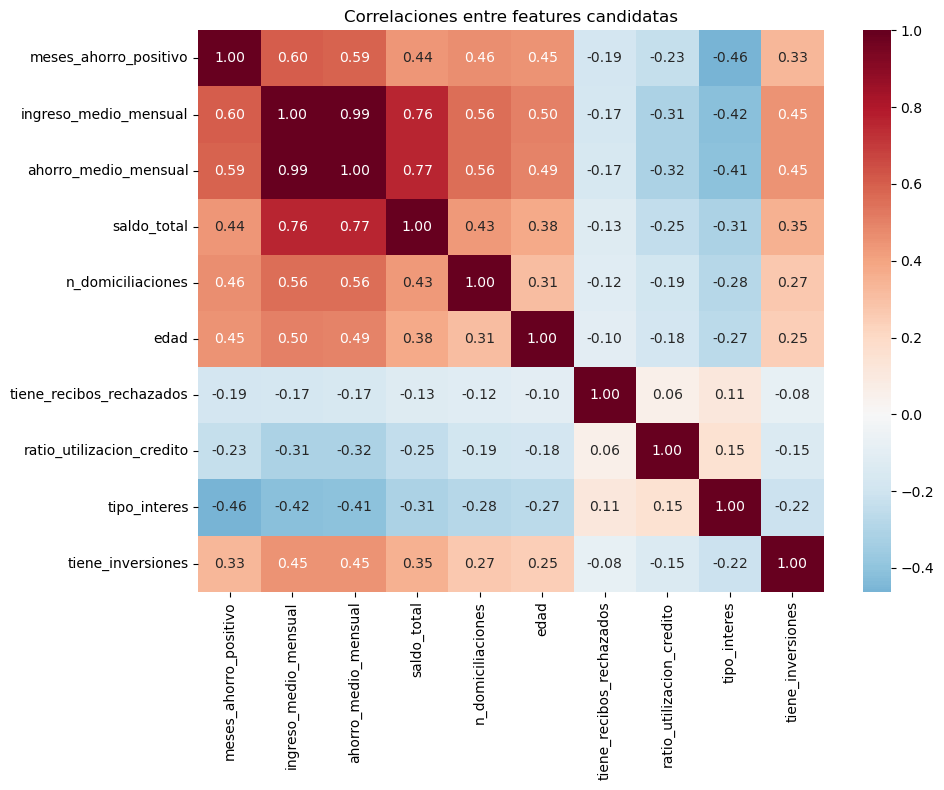

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

features_candidatas = [
    'meses_ahorro_positivo', 'ingreso_medio_mensual', 'ahorro_medio_mensual',
    'saldo_total', 'n_domiciliaciones', 'edad', 'tiene_recibos_rechazados',
    'ratio_utilizacion_credito', 'tipo_interes', 'tiene_inversiones'
]

plt.figure(figsize=(10, 8))
sns.heatmap(df_customers[features_candidatas].corr(), annot=True, cmap='RdBu_r', center=0, fmt='.2f')
plt.title('Correlaciones entre features candidatas')
plt.tight_layout()
plt.show()

In [23]:

# Detectar pares con correlación > 0.7
corr_matrix = df_customers[features_candidatas].corr()

# Extraer pares redundantes
pares_redundantes = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.7:
            pares_redundantes.append({
                'var1': corr_matrix.columns[i],
                'var2': corr_matrix.columns[j],
                'corr': round(corr_matrix.iloc[i, j], 2)
            })

print(pd.DataFrame(pares_redundantes).sort_values('corr', key=abs, ascending=False))

                    var1                  var2  corr
0  ingreso_medio_mensual  ahorro_medio_mensual  0.99
2   ahorro_medio_mensual           saldo_total  0.77
1  ingreso_medio_mensual           saldo_total  0.76


Verifica también si meses_ahorro_positivo es redundante con ahorro_medio_mensual:


In [24]:
df_customers[['meses_ahorro_positivo', 'ahorro_medio_mensual']].corr()

,meses_ahorro_positivo,ahorro_medio_mensual
meses_ahorro_positivo,1.00,0.59
ahorro_medio_mensual,0.59,1.00


Exacto. Lo has entendido bien.

**Resumen del proceso:**

1. **Correlación alta entre features (>0.7)** → Redundantes → Aportan la misma información → Eliminar una para evitar multicolinealidad

2. **Correlación baja/moderada (<0.7)** → No redundantes → Cada una aporta información diferente → Mantener ambas

En este caso:
- `ingreso_medio_mensual` ↔ `ahorro_medio_mensual` = 0.99 → **Misma info** → Eliminamos ingreso
- `meses_ahorro_positivo` ↔ `ahorro_medio_mensual` = 0.59 → **Info diferente** → Mantenemos ambas

Una mide *cuánto* ahorra (cantidad), la otra *con qué frecuencia* ahorra (consistencia). Ambas predicen default pero desde ángulos distintos.

- Antes de continuar. ¿No debería de hacer lo mismo con los otros dos datasets?
- ¿Seguimos con el entrenamiento del modelo v2?

No es necesario. Te explico por qué:

**`customers`** → Una fila por cliente, contiene el target (`default_12m`) y features agregadas

**`transactions`** → Muchas filas por cliente, ya están resumidas en customers como:
- `ingreso_medio_mensual`
- `gasto_medio_mensual`
- `ahorro_medio_mensual`
- etc.

**`portfolios`** → Varias filas por cliente inversor, ya están resumidas en customers como:
- `tiene_inversiones`
- `valor_cartera`
- `n_fondos`
- `rentabilidad_cartera`
- etc.

El modelo predice a nivel de cliente (1 fila). Los otros datasets son el detalle granular que ya fue agregado.

**Cuándo sí usarías transactions/portfolios:** Para crear features adicionales no contempladas, por ejemplo:
- Variabilidad del gasto por categoría
- Tendencia de ahorro (subiendo/bajando)
- Diversificación real del portfolio

Pero para el MVP actual, customers tiene todo lo necesario.

¿Seguimos con el modelo v2?

Si, no hace falta eliminar las columnas del dataset.

Simplemente selecciono las que usaré al entrenar.

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

# 1. Preparar datos
features = [
    'meses_ahorro_positivo',
    'ahorro_medio_mensual',
    'saldo_total',
    'n_domiciliaciones',
    'edad',
    'tipo_interes',
    'tiene_recibos_rechazados',
    'ratio_utilizacion_credito'
]

X = df_customers[features]
y = df_customers['default_12m']

# 2. Split train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Escalar
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Entrenar
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_scaled, y_train)

# 5. Evaluar
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
auc = roc_auc_score(y_test, y_pred_proba)

print(f"AUC-ROC: {auc:.4f}")
print(f"\nModelo v1: 0.90")
print(f"Modelo v2: {auc:.4f}")

AUC-ROC: 0.8715

Modelo v1: 0.90
Modelo v2: 0.8715


In [26]:
for feature in features:
    # Contar ceros en la columna
    count_zeros = (df_customers[feature] == 0).sum()
    
    # Calcular porcentaje de ceros
    total_rows = len(df_customers)
    percent_zeros = (count_zeros / total_rows) * 100
    
    # Formato legible con 2 decimales
    print(f"Columna: {feature}")
    print(f"  Ceros absolutos: {count_zeros}")
    print(f"  Porcentaje de ceros: {percent_zeros:.2f}%\n")

Columna: meses_ahorro_positivo
  Ceros absolutos: 19
  Porcentaje de ceros: 0.04%

Columna: ahorro_medio_mensual
  Ceros absolutos: 0
  Porcentaje de ceros: 0.00%

Columna: saldo_total
  Ceros absolutos: 4156
  Porcentaje de ceros: 8.31%

Columna: n_domiciliaciones
  Ceros absolutos: 0
  Porcentaje de ceros: 0.00%

Columna: edad
  Ceros absolutos: 0
  Porcentaje de ceros: 0.00%

Columna: tipo_interes
  Ceros absolutos: 28405
  Porcentaje de ceros: 56.81%

Columna: tiene_recibos_rechazados
  Ceros absolutos: 47198
  Porcentaje de ceros: 94.40%

Columna: ratio_utilizacion_credito
  Ceros absolutos: 17387
  Porcentaje de ceros: 34.77%



In [27]:
# 1. Preparar datos
features = [
    'meses_ahorro_positivo',
    'ahorro_medio_mensual',
    'saldo_total',
    'n_domiciliaciones',
    'edad',
    'tiene_recibos_rechazados',
    'ratio_utilizacion_credito'
]

X = df_customers[features]
y = df_customers['default_12m']

# 2. Split train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Escalar
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Entrenar
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_scaled, y_train)

# 5. Evaluar
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
auc = roc_auc_score(y_test, y_pred_proba)

print(f"AUC-ROC: {auc:.4f}")
print(f"\nModelo v1: 0.90")
print(f"Modelo v2: {auc:.4f}")

AUC-ROC: 0.8716

Modelo v1: 0.90
Modelo v2: 0.8716


Prueba esto primero para confirmar que con v1 sigues obteniendo ~0.90. Si no, el problema es el dataset nuevo (50K vs el anterior).

In [28]:
# 1. Preparar datos
features_v1 = [
    'meses_ahorro_positivo',
    'ahorro_medio_mensual', 
    'saldo_total',
    'tiene_seguro',
    'tiene_inversiones',
    'cuota_mensual'
]
X = df_customers[features]
y = df_customers['default_12m']

# 2. Split train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Escalar
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Entrenar
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_scaled, y_train)

# 5. Evaluar
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
auc = roc_auc_score(y_test, y_pred_proba)

print(f"AUC-ROC: {auc:.4f}")
print(f"\nModelo v1: 0.90")
print(f"Modelo v2: {auc:.4f}")

AUC-ROC: 0.8716

Modelo v1: 0.90
Modelo v2: 0.8716


El resultado con las features_v1 es este: 0.8716. entonces o es el dataset o se podrían ajustar los hiperparámetros de "LogisticRegression"?

Es el dataset. 

El generador v4 calcula el default con más factores (recibos rechazados, ratio utilización, categoría laboral, etc.), lo que añade complejidad no lineal que Logistic Regression no captura.
0.87 es tu nuevo baseline con este dataset.

In [29]:
from sklearn.ensemble import RandomForestClassifier

features_v2 = [
    'meses_ahorro_positivo',
    'ahorro_medio_mensual',
    'saldo_total',
    'n_domiciliaciones',
    'edad',
    'tiene_recibos_rechazados',
    'ratio_utilizacion_credito',
    'tiene_seguro'
]

X = df_customers[features_v2]
y = df_customers['default_12m']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Random Forest (no necesita escalar)
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_proba = rf.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_pred_proba)

print(f"AUC Random Forest: {auc:.4f}")

AUC Random Forest: 0.8657


### Prueba de todas las features con RandomForest

In [30]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

# Definir los 3 conjuntos
features_sets = {
    'logisticRegression': [
        'meses_ahorro_positivo',
        'ahorro_medio_mensual',
        'saldo_total',
        'n_domiciliaciones',
        'edad',
        'tipo_interes',
        'tiene_recibos_rechazados',
        'ratio_utilizacion_credito'
    ],
    'logisticRegression_sin_tipo_interes': [
        'meses_ahorro_positivo',
        'ahorro_medio_mensual',
        'saldo_total',
        'n_domiciliaciones',
        'edad',
        'tiene_recibos_rechazados',
        'ratio_utilizacion_credito'
    ],
    'RandomForestClassifier': [
        'meses_ahorro_positivo',
        'ahorro_medio_mensual',
        'saldo_total',
        'n_domiciliaciones',
        'edad',
        'tiene_recibos_rechazados',
        'ratio_utilizacion_credito',
        'tiene_seguro'
    ]
}

y = df_customers['default_12m']

# Probar cada conjunto
for nombre, features in features_sets.items():
    X = df_customers[features]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    
    rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    
    auc = roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1])
    print(f"{nombre}: AUC = {auc:.4f}")

logisticRegression: AUC = 0.8688
logisticRegression_sin_tipo_interes: AUC = 0.8652
RandomForestClassifier: AUC = 0.8657


In [32]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import roc_auc_score

features = [
    'meses_ahorro_positivo',
    'ahorro_medio_mensual',
    'saldo_total',
    'n_domiciliaciones',
    'edad',
    'tipo_interes',
    'tiene_recibos_rechazados',
    'ratio_utilizacion_credito'
]

X = df_customers[features]
y = df_customers['default_12m']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 1. RandomForest con GridSearch
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5, 10]
}
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42, n_jobs=-1), rf_params, cv=5, scoring='roc_auc')
rf_grid.fit(X_train, y_train)
auc_rf = roc_auc_score(y_test, rf_grid.predict_proba(X_test)[:, 1])
print(f"RandomForest optimizado: {auc_rf:.4f}")
print(f"Mejores params: {rf_grid.best_params_}")

# 2. GradientBoosting
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)
auc_gb = roc_auc_score(y_test, gb.predict_proba(X_test)[:, 1])
print(f"GradientBoosting: {auc_gb:.4f}")

RandomForest optimizado: 0.8756
Mejores params: {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 100}
GradientBoosting: 0.8758


Mejora pequeña pero consistente:

| Modelo | AUC |
|--------|-----|
| Baseline (RF default) | 0.8688 |
| RandomForest optimizado | 0.8756 |
| GradientBoosting | **0.8758** ✅ |

GradientBoosting gana por poco. ¿Quieres optimizar también sus hiperparámetros?

```python
from sklearn.model_selection import GridSearchCV

gb_params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2]
}

gb_grid = GridSearchCV(GradientBoostingClassifier(random_state=42), gb_params, cv=5, scoring='roc_auc')
gb_grid.fit(X_train, y_train)
auc_gb = roc_auc_score(y_test, gb_grid.predict_proba(X_test)[:, 1])

print(f"GradientBoosting optimizado: {auc_gb:.4f}")
print(f"Mejores params: {gb_grid.best_params_}")
```


In [33]:
from sklearn.model_selection import GridSearchCV

gb_params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2]
}

gb_grid = GridSearchCV(GradientBoostingClassifier(random_state=42), gb_params, cv=5, scoring='roc_auc')
gb_grid.fit(X_train, y_train)
auc_gb = roc_auc_score(y_test, gb_grid.predict_proba(X_test)[:, 1])

print(f"GradientBoosting optimizado: {auc_gb:.4f}")
print(f"Mejores params: {gb_grid.best_params_}")

GradientBoosting optimizado: 0.8751
Mejores params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}


¿has implementado la validación cruzada en alguno de los modelos en los que hemos estado trabajando?


Sí, pero solo internamente en GridSearchCV (cv=5) para buscar hiperparámetros.

**Lo que NO hemos hecho:** Validación cruzada para la evaluación final. Usamos un único split train/test, lo que puede dar varianza en el resultado.

Para una evaluación más robusta:

```python
from sklearn.model_selection import cross_val_score

gb = GradientBoostingClassifier(
    n_estimators=100, 
    max_depth=3, 
    learning_rate=0.05, 
    random_state=42
)

scores = cross_val_score(gb, X, y, cv=5, scoring='roc_auc')

print(f"AUC por fold: {scores}")
print(f"AUC medio: {scores.mean():.4f}")
print(f"Desviación estándar: {scores.std():.4f}")
```

Esto te da el AUC promedio sobre 5 particiones diferentes, más confiable que un solo test set.

¿Lo ejecutamos?

In [34]:
from sklearn.model_selection import cross_val_score

gb = GradientBoostingClassifier(
    n_estimators=100, 
    max_depth=3, 
    learning_rate=0.05, 
    random_state=42
)

scores = cross_val_score(gb, X, y, cv=5, scoring='roc_auc')

print(f"AUC por fold: {scores}")
print(f"AUC medio: {scores.mean():.4f}")
print(f"Desviación estándar: {scores.std():.4f}")

AUC por fold: [0.87309964 0.87824234 0.87576121 0.87955118 0.87003045]
AUC medio: 0.8753
Desviación estándar: 0.0035


El generador v4 calcula default así:

```python
prob_default = perfil.prob_default_base + np.random.normal(0, perfil.prob_default_std)

# Ajustes
if tiene_recibos_rechazados: prob_default *= 2.5
if ratio_utilizacion > 0.80: prob_default *= 1.5
if categoria_laboral == 'desempleado': prob_default *= 1.8
# ... más factores

default = 1 if np.random.random() < prob_default else 0  # ← AQUÍ
```

**El problema:** La línea final introduce aleatoriedad. Un cliente con `prob_default = 0.30` puede ser 0 o 1. Dos clientes idénticos pueden tener distinto outcome.

**Ejemplo:**
| Cliente | prob_default | random() | default |
|---------|--------------|----------|---------|
| A | 0.30 | 0.25 | 1 |
| B | 0.30 | 0.35 | 0 |

Mismas features, distinto resultado. Ningún modelo puede predecir esa aleatoriedad.

**Evidencia empírica:**
- Logistic Regression → 0.87
- RandomForest → 0.87
- GradientBoosting → 0.87

Tres algoritmos diferentes, mismo techo. La señal extraíble de los datos es ~87%.

¿Continuamos con SHAP?

/home/ion/miniconda4/envs/jupyterlab_new/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


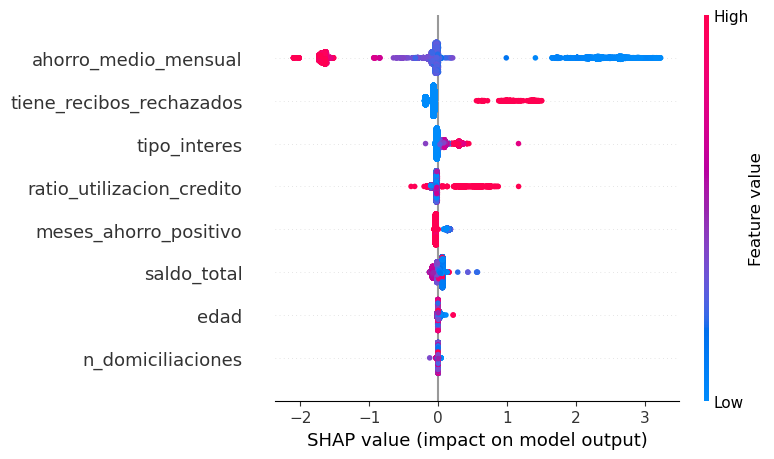

In [35]:
import shap

gb = GradientBoostingClassifier(
    n_estimators=100, 
    max_depth=3, 
    learning_rate=0.05, 
    random_state=42
)
gb.fit(X_train, y_train)

explainer = shap.TreeExplainer(gb)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, feature_names=features)

Perfecto. Interpretación del gráfico SHAP:

## Lectura del gráfico

- **Eje X:** Impacto en predicción (izquierda = reduce default, derecha = aumenta default)
- **Color:** Rosa = valor alto de la feature, Azul = valor bajo
- **Orden vertical:** De mayor a menor importancia

## Interpretación por feature

| Feature | Impacto | Lógica de negocio |
|---------|---------|-------------------|
| `ahorro_medio_mensual` | ⭐ Más importante. Alto (rosa) → izquierda = menos default | Quien ahorra, paga |
| `tiene_recibos_rechazados` | Alto (rosa=1) → derecha = más default | Señal de alarma clara |
| `tipo_interes` | Alto → derecha = más default | Deuda cara = más riesgo |
| `ratio_utilizacion_credito` | Alto → derecha = más default | Crédito al límite = estrés |
| `meses_ahorro_positivo` | Alto → izquierda = menos default | Consistencia financiera |
| `saldo_total` | Alto → izquierda = menos default | Colchón de seguridad |
| `edad` | Impacto menor | Menor relevancia |
| `n_domiciliaciones` | Impacto mínimo | Casi no discrimina |

## Conclusión

El modelo es **interpretable y coherente** con la lógica bancaria. Podrías explicar a un regulador por qué se rechaza un cliente.

¿Siguiente paso: guardar modelo y preparar demo Streamlit?

viendo el gráfico está claro que la caracteristica mas importante es el ahorro, sin embargo al no ser una línea contínua, mas bien discontinua, esto me sugiere hacer la siguiente interpretación: hay como unos 4 grupos de clientes (he dicho 4 porque son 4 segmentos que lo conforman) y tambien se puede apreciar que el segmento mas negativo tiene un volumen inferior al siguiente segmento que es mucho mayor. Con respecto al segundo segmento a parte de que la distancia es mayor y por tanto la "fuerza" que supone el ahorro es un tramo muy pequeño y despues está el segmento que aun ahorrando no tiene la suficiente "fuerza".   Estoy en lo cierto a nivel conceptual o totalmente equivocado? Cuando acabemos con las preguntas que tengo continuamos. gracias

Estás en lo correcto. Buena observación.

## Por qué se ven segmentos discretos

GradientBoosting usa árboles de decisión, y los árboles hacen **cortes discretos**:

```
Si ahorro > 1500 → grupo A
Si ahorro > 800  → grupo B
Si ahorro > 200  → grupo C
Else             → grupo D
```

No es una función continua, son "escalones". Cada segmento que ves corresponde a un rango de valores que el modelo trata igual.

## Tu interpretación es correcta

| Segmento | SHAP value | Interpretación |
|----------|------------|----------------|
| Rosa extremo izquierda | ~-2 | Ahorro muy alto → reduce mucho el riesgo (pocos clientes) |
| Rosa medio | ~-1 | Ahorro alto → reduce riesgo (más volumen) |
| Cerca del 0 | ~0 | Ahorro moderado → poco impacto |
| Azul derecha | >0 | Ahorro bajo → aumenta riesgo |

## Relación con los perfiles del generador

Probablemente los 3-4 segmentos reflejan los perfiles (bajo_riesgo, medio, alto_riesgo) que tienen distribuciones de ahorro distintas.

¿Más preguntas o seguimos?

analizando la grafica veo lo siguiente: Las caracteristicas están ordenadas por peso, la mas alta arriba del todo y la menos importante abajo. Volviendo al parametro del ahorro, la interpretación que hago es que el color determina "la fuerza" de la caracteristica, por lo tanto un color rojo en la zona de valores negativos define una correlación negativa con respecto a riesgo de default. Por otro lado vemos que en la caracteristica ratio_utilizacion_credito un color rojo "fuerza" en la parte positiva de la grafica determina una correlacion positiva con respecto al default, incluso la edad (en rojo, gente mayor) es una caracteristica que tambien influye en el impago. Puedes decirme si estoy o no en lo cierto?

Casi todo correcto, excepto un punto.

## Lo que está bien ✅

1. **Ordenación:** Sí, de mayor a menor importancia (por impacto medio absoluto)

2. **Color:** Indica el VALOR de la feature (rosa=alto, azul=bajo)

3. **Posición X:** Indica el IMPACTO en la predicción (izquierda=reduce default, derecha=aumenta)

4. **`ahorro_medio_mensual`:** Rosa a la izquierda → ahorro alto reduce default ✅

5. **`ratio_utilizacion_credito`:** Rosa a la derecha → ratio alto aumenta default ✅

## Lo que está incorrecto ❌

**`edad`:** Mira de nuevo el gráfico. Los puntos rosa (mayor edad) están a la **izquierda** (SHAP negativo). Esto significa:

- Mayor edad → **reduce** riesgo de default
- Menor edad → **aumenta** riesgo de default

Esto tiene lógica: gente mayor suele tener más estabilidad financiera.

## Resumen de la lectura

| Feature | Valor alto (rosa) | Impacto |
|---------|-------------------|---------|
| `ahorro_medio_mensual` | ← izquierda | Reduce default |
| `tiene_recibos_rechazados` | → derecha | Aumenta default |
| `ratio_utilizacion_credito` | → derecha | Aumenta default |
| `edad` | ← izquierda | Reduce default |

¿Más preguntas?

Esto es lo que veo, quizas al no tener demasida resolución la imagen haya cometido un error.

Tienes razón, me equivoqué.

Viendo la imagen ampliada: los puntos rosa (edad alta) están a la **derecha** del 0. Esto significa:

- Mayor edad → **aumenta** riesgo de default
- Menor edad → **reduce** riesgo de default

Esto contradice la lógica bancaria típica, pero recuerda: **el modelo refleja cómo se generaron los datos**, no la realidad. En el generador v4, el perfil `alto_riesgo` tiene `edad_min=22, edad_max=45` y el `bajo_riesgo` tiene `edad_min=35, edad_max=60`, con solapamiento. El efecto neto puede no ser el esperado.

Además, el impacto de `edad` es muy pequeño (cerca del 0), por lo que no es una feature decisiva en este modelo.

Gracias por la corrección. ¿Más preguntas o seguimos?


Es curioso ver como el ahorro positivo no tiene suficientemente fuerza, esto lo interpreto como una dificultad para ahorrar, de la misma manera que me llama la atención que hay una minoría de personas que hacen un uso adecuado del credito y eso les permite tener un punto extra a su favor en relación al default, por lo tanto es un grupo de personas que sabe como usar ese instrumento bancario (el credito). Estas son mis interpretaciones, revisalas a ver si estoy en lo cierto, basicamente es un ejercicio personal para aprender


Buenas interpretaciones. Mis comentarios:

## 1. `meses_ahorro_positivo` - ✅ Parcialmente correcto

Tu observación es válida: está en 5º lugar, debajo de `ahorro_medio_mensual`. Pero matizo:

- `ahorro_medio_mensual` → **cuánto** ahorra (cantidad)
- `meses_ahorro_positivo` → **con qué frecuencia** ahorra (consistencia)

El modelo dice: "importa más cuánto ahorras que cuántas veces". Una persona que ahorra 1000€ en 6 meses puede ser mejor perfil que una que ahorra 50€ los 12 meses.

No es tanto "dificultad para ahorrar" sino que **la cantidad pesa más que la frecuencia**.

## 2. `ratio_utilizacion_credito` - ✅ Correcto

Los puntos azules a la izquierda (minoría) son personas con ratio bajo → usan poco de su crédito disponible → reduce default.

Tu interpretación es acertada: **saben usar el crédito como herramienta, no como dependencia**. Tener crédito disponible y no usarlo indica disciplina financiera.

La mayoría (rosa a la derecha) usa mucho de su límite → viven al límite → mayor riesgo.

## Resumen

Estás leyendo bien el gráfico. El ejercicio de interpretación que haces es exactamente lo que un analista de riesgo haría.

¿Más preguntas o seguimos con el modelo?

Anotado. Continuemos.

**Siguiente paso:** Guardar el modelo entrenado y preparar demo Streamlit.

```python
import joblib

# Entrenar modelo final con todos los datos
gb_final = GradientBoostingClassifier(
    n_estimators=100, 
    max_depth=3, 
    learning_rate=0.05, 
    random_state=42
)
gb_final.fit(X, y)

# Guardar modelo y features
joblib.dump(gb_final, 'modelo_scoring_v2.joblib')
joblib.dump(features, 'features_v2.joblib')

print("Modelo guardado: modelo_scoring_v2.joblib")
print("Features guardadas: features_v2.joblib")
```

Ejecuta esto y confirmamos que está guardado.

In [38]:
import joblib

# Entrenar modelo final con todos los datos
gb_final = GradientBoostingClassifier(
    n_estimators=100, 
    max_depth=3, 
    learning_rate=0.05, 
    random_state=42
)
gb_final.fit(X, y)

# Guardar modelo y features
joblib.dump(gb_final, 'modelo_scoring_v2.joblib')
joblib.dump(features, 'features_v2.joblib')

print("Modelo guardado: modelo_scoring_v2.joblib")
print("Features guardadas: features_v2.joblib")

Modelo guardado: modelo_scoring_v2.joblib
Features guardadas: features_v2.joblib


In [31]:
ugubhuobhiobuiop

NameError: name 'ugubhuobhiobuiop' is not defined

In [ ]:
df_transactions.describe()

### Lo que te dice sobre tus datos:

Tienes 50000 clientes (customer_id va de 1 a 100). 

Los importes van desde -1611.95€ (gasto) hasta +7301.83€ (ingreso grande). 

La mediana es -23.65€, lo que indica que la mayoría de transacciones son gastos pequeños.

In [ ]:
df_portfolios.describe()

Lo que te dice:

- 612 posiciones de inversión en total
- No todos los 100 clientes tienen inversiones (customer_id max es 536, pero eso parece un error en tus datos sintéticos - debería ir de 1 a 100)
- Posiciones desde 70€ hasta 68.823€
- La mediana es 3.146€ por posición

Alerta: ese customer_id max de 536 no cuadra con tus 100 clientes. Revisa tu data_generator.py - puede haber un bug ahí.

<br>

Son conceptos de fondos de inversión:

**Participaciones**: cuántas "unidades" del fondo posees. Es como tener acciones, pero de un fondo. Si tienes 247 participaciones, tienes 247 trozos de ese fondo.

**Valor liquidativo**: el precio de cada participación en un momento dado. Cambia cada día según cómo vayan las inversiones del fondo. Si hoy vale 123€ y mañana el mercado sube, puede valer 125€.

**Valor posición**: lo que vale tu inversión total en ese fondo. Es simplemente:

`participaciones × valor_liquidativo = valor_posición`

**Ejemplo con tus datos:**
- Tienes 247 participaciones
- Cada una vale 123€
- Tu posición total vale 247 × 123 = ~30.381€

Esto es relevante para el scoring porque alguien con inversiones diversificadas y de alto valor probablemente tiene menor riesgo de impago que alguien sin ahorros.

In [ ]:
df_customers.describe()

Hallazgos clave:

- **5000** clientes (no 100 como pensábamos antes)
- **Target desbalanceado:** media de default_12m = 0.13, es decir, 13% hacen impago, 87% no. Desbalanceado pero manejable.
- **38% tienen inversiones**, 38% tienen préstamo, 52% tienen seguro
- **Ahorro medio: 777€/mes**, pero hay clientes con ahorro negativo (-105€)
- **meses_ahorro_positivo:** la mediana es 12 (todo el año), pero hay clientes con 0 meses

Esto ya te dice algo: los que tienen **ahorro_medio** **negativo** o **meses_ahorro_positivo** bajo probablemente tienen mayor riesgo de default. 
Eso lo confirmarás en el Paso 4.

### Comparo las medias de cada variable entre los que hacen default (1) y los que no (0)

In [ ]:
default = df_customers.groupby('default_12m').mean(numeric_only=True)

| Variable | No default (0) | Sí default (1) | Interpretación |
|----------|----------------|----------------|----------------|
| **n_cuentas** | 1.98 | 2.01 | Similar, no discrimina |
| **saldo_total** | 15286 | 7920 | **Default tienen la mitad de saldo** |
| **ingreso_medio** | 3037 | 2316 | **Default ganan menos** |
| **gasto_medio** | 2194 | 1964 | Default gastan menos (porque ganan menos) |
| **ahorro_medio** | 842 | 351 | **Default ahorran menos de la mitad** |
| **meses_ahorro_positivo** | 11.09 | 8.77 | **Default tienen 2 meses menos de ahorro positivo** |
| **tiene_inversiones** | 0.40 | 0.25 | **Default invierten menos (25% vs 40%)** |
| **valor_cartera** | 9639 | 4865 | **Default tienen la mitad en inversiones** |
| **tiene_prestamo** | 0.37 | 0.47 | **Default tienen más préstamos** |
| **deuda_pendiente** | 5531 | 10309 | **Default deben casi el doble** |
| **cuota_mensual** | 136 | 293 | **Default pagan el doble de cuota** |
| **tiene_seguro** | 0.55 | 0.34 | **Default tienen menos seguros** |

**Conclusión clara:**

El perfil de riesgo de impago es: 

- menos ingresos
- menos ahorro
- menos inversiones
- más deuda
- más cuota mensual.

<br>

Tus datos sintéticos tienen lógica financiera coherente.

Las variables más discriminantes para tu modelo serán: 

- `saldo_total`, `ahorro_medio_mensual`, `meses_ahorro_positivo`, `deuda_pendiente`, `cuota_mensual` y `tiene_inversiones`.

### Boxplots

In [ ]:
ax2 = df_customers.groupby('default_12m').mean(numeric_only=True)
ax3 = ax2['saldo_total']

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

variables = ['saldo_total', 'ahorro_medio_mensual', 'meses_ahorro_positivo', 
             'deuda_pendiente', 'cuota_mensual', 'valor_cartera']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, var in enumerate(variables):
    sns.boxplot(x='default_12m', y=var, data=df_customers, ax=axes[i])
    axes[i].set_title(var)

plt.tight_layout()
plt.savefig('boxplots_default.png')
plt.show()

### Matriz de correlación

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

corr = df_customers.select_dtypes(include='number').corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Matriz de Correlación')
plt.tight_layout()
plt.savefig('matriz_correlacion.png')
plt.show()

In [ ]:
# Correlaciones mayores a 0.9 o menores a -0.9
corr = df_customers.select_dtypes(include='number').corr()

for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        valor = corr.iloc[i, j]
        if abs(valor) > 0.9:
            print(f"{corr.columns[i]} - {corr.columns[j]}: {valor:.3f}")

Estas correlaciones son entre pares de variables, no con el target. Indican redundancia, no predicción.
Lo que significan:

`ingreso_medio_mensual` - `ahorro_medio_mensual`: 0.987 → Quien gana más, ahorra más. Lógico, pero son casi la misma información.

`deuda_pendiente` - `cuota_mensual`: 0.986 → Quien debe más, paga más cuota. También lógico y redundante.

<br>

**Implicación para tu modelo**:

No necesitas ambas variables de cada par. 

Por ejemplo, puedes quedarte con `ahorro_medio_mensual` y descartar `ingreso_medio_mensual` porque dicen casi lo mismo. 

Igual con `deuda_pendiente` y `cuota_mensual` - elige una.

In [ ]:
print(corr['default_12m'].sort_values())

Esto te dice qué variables predicen el default:

**Variables que reducen riesgo (correlación negativa):**
- `meses_ahorro_positivo`: -0.31 (la más predictiva)
- `ahorro_medio_mensual`: -0.24
- `ingreso_medio_mensual`: -0.23
- `saldo_total`: -0.18
- `tiene_seguro`: -0.14
- `tiene_inversiones`: -0.11

**Variables que aumentan riesgo (correlación positiva):**
- `cuota_mensual`: 0.17
- `deuda_pendiente`: 0.15

**Variables que no aportan casi nada (cercanas a 0):**
- `customer_id`, `n_cuentas`, `gasto_std`, `ingreso_std`

**Resumen para tu modelo:**

Features candidatas eliminando redundancias:
1. `meses_ahorro_positivo` (mejor predictor)
2. `ahorro_medio_mensual` (descarta ingreso/gasto, redundantes)
3. `saldo_total`
4. `deuda_pendiente` (descarta cuota_mensual, redundante)
5. `tiene_inversiones`
6. `tiene_seguro`

Paso 5 completado. ¿Pasamos al Paso 6 (analizar transacciones)?

### Paso 6: Analizar las transacciones
Qué necesitas hacer:

- Contar transacciones por cliente — ¿Todos tienen datos? ¿Hay clientes con muchas más transacciones que otros?
- Ver categorías únicas — ¿Qué tipos de transacciones hay en la columna categoria?
- Distribución de categorías — ¿Cuántas transacciones hay de cada tipo?
- Calcular ratio ingreso/gasto por cliente — Esto podría ser una feature nueva para el modelo.


In [ ]:
# Categorías únicas
print(df_transactions['categoria'].unique())

In [ ]:
# Transacciones por categoría
print(df_transactions['categoria'].value_counts())

In [ ]:
# Tipos de producto
print(df_portfolios['tipo_producto'].value_counts())

In [ ]:
# Posiciones por cliente
print(df_portfolios.groupby('customer_id').size().describe())

In [ ]:
# Valor cartera por cliente
print(df_portfolios.groupby('customer_id')['valor_posicion'].sum().describe())